<a href="https://colab.research.google.com/github/Hmm-Asadullah/Decision-tree-and-K-means-clustering/blob/main/BSEF23M012_Asdadullah_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import warnings
# warnings.filterwarnings('ignore')


# Task No 01 — Decision Tree


## 1.1 Dataset Loading and Preprocessing
### a) Load the Dataset

In [7]:
column_names = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring',
    'veil-type', 'veil-color', 'ring-number', 'ring-type',
    'spore-print-color', 'population', 'habitat'
]

df = pd.read_csv('mushroom.csv', header=None, names=column_names)

print("First 5 rows:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['class'].value_counts())
print(f"\n  Edible (e):    {(df['class']=='e').sum()}")
print(f"  Poisonous (p): {(df['class']=='p').sum()}")


First 5 rows:
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p         

### b) Handle Missing Values

In [8]:
cols_with_missing = [col for col in df.columns if (df[col] == '?').any()]
print(f"Columns with '?' values: {cols_with_missing}")

for col in cols_with_missing:
    count = (df[col] == '?').sum()
    mode_val = df[df[col] != '?'][col].mode()[0]
    print(f"  '{col}': {count} missing values → replacing with mode='{mode_val}'")
    df[col] = df[col].replace('?', mode_val)

print("\nMissing values after replacement:", (df == '?').sum().sum())


Columns with '?' values: ['stalk-root']
  'stalk-root': 2480 missing values → replacing with mode='b'

Missing values after replacement: 0


### c) Encode Features

In [9]:
encoders = {}

df_encoded = df.copy()
for col in df_encoded.columns:
    unique_vals = sorted(df_encoded[col].unique())
    mapping = {v: i for i, v in enumerate(unique_vals)}
    encoders[col] = mapping
    df_encoded[col] = df_encoded[col].map(mapping)

print("Encoding complete. Sample mappings:")
print(f"  class: {encoders['class']}")
print(f"  odor:  {encoders['odor']}")
print("\nFirst 5 encoded rows:")
print(df_encoded.head())


Encoding complete. Sample mappings:
  class: {'e': 0, 'p': 1}
  odor:  {'a': 0, 'c': 1, 'f': 2, 'l': 3, 'm': 4, 'n': 5, 'p': 6, 's': 7, 'y': 8}

First 5 encoded rows:
   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      1          5            2          4        1     6                1   
1      0          5            2          9        1     0                1   
2      0          0            2          8        1     3                1   
3      1          5            3          8        1     6                1   
4      0          5            2          3        0     5                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          1           4  ...                         2   
1             0          0           4  ...                         2   
2             0          0           5  ...                         2   
3             0          1           5  ...                       

### d) Train/Test Split

In [10]:
np.random.seed(42)
indices = np.arange(len(df_encoded))
np.random.shuffle(indices)

split_idx = int(0.8 * len(indices))
train_idx = indices[:split_idx]
test_idx  = indices[split_idx:]

X = df_encoded.drop(columns=['class']).values
y = df_encoded['class'].values
feature_names = df_encoded.drop(columns=['class']).columns.tolist()

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f"Total samples:  {len(df_encoded)}")
print(f"Training set:   {len(X_train)} samples ({len(X_train)/len(df_encoded)*100:.1f}%)")
print(f"Test set:       {len(X_test)} samples  ({len(X_test)/len(df_encoded)*100:.1f}%)")


Total samples:  8124
Training set:   6499 samples (80.0%)
Test set:       1625 samples  (20.0%)



## 1.2 Manual Entropy and Information Gain Calculation

In [15]:
n_total = len(y_train)
n_edible    = np.sum(y_train == encoders['class']['e'])
n_poisonous = np.sum(y_train == encoders['class']['p'])

p_e = n_edible    / n_total
p_p = n_poisonous / n_total

H_root = -p_e * np.log2(p_e) - p_p * np.log2(p_p)

print("  ROOT ENTROPY CALCULATION")
print(f"  Training samples (N) : {n_total}")
print(f"  Edible  (n_e)        : {n_edible}  →  p_e = {p_e:.4f}")
print(f"  Poisonous (n_p)      : {n_poisonous} →  p_p = {p_p:.4f}")
print(f"  H(S) = -({p_e:.4f})log2({p_e:.4f}) - ({p_p:.4f})log2({p_p:.4f})")
print(f"  H(S) = {H_root:.4f}")

odor_idx = feature_names.index('odor')
odor_col  = X_train[:, odor_idx]
odor_inv  = {v: k for k, v in encoders['odor'].items()}

print("\n  INFORMATION GAIN — odor")
weighted_H = 0.0
for val in np.unique(odor_col):
    mask      = odor_col == val
    subset_y  = y_train[mask]
    prop      = mask.sum() / n_total
    if len(subset_y) == 0:
        h_v = 0
    else:
        counts = np.bincount(subset_y, minlength=2)
        probs  = counts / counts.sum()
        probs  = probs[probs > 0]
        h_v    = -np.sum(probs * np.log2(probs))
    weighted_H += prop * h_v
    print(f"  odor='{odor_inv[val]}': |S_v|={mask.sum():4d}, prop={prop:.4f}, H={h_v:.4f}, contrib={prop*h_v:.4f}")

IG_odor = H_root - weighted_H
print(f"\n  H(S|odor)  = {weighted_H:.4f}")
print(f"  IG(S,odor) = {H_root:.4f} - {weighted_H:.4f} = {IG_odor:.4f}")

gc_idx  = feature_names.index('gill-color')
gc_col  = X_train[:, gc_idx]

weighted_H_gc = 0.0
for val in np.unique(gc_col):
    mask     = gc_col == val
    subset_y = y_train[mask]
    prop     = mask.sum() / n_total
    if len(subset_y) == 0:
        h_v = 0
    else:
        counts = np.bincount(subset_y, minlength=2)
        probs  = counts / counts.sum()
        probs  = probs[probs > 0]
        h_v    = -np.sum(probs * np.log2(probs))
    weighted_H_gc += prop * h_v

IG_gc = H_root - weighted_H_gc
print(f"\n  IG(S, gill-color) = {H_root:.4f} - {weighted_H_gc:.4f} = {IG_gc:.4f}")

print("  COMPARISON")
print(f"  IG(S, odor)       = {IG_odor:.4f}")
print(f"  IG(S, gill-color) = {IG_gc:.4f}")
winner = 'odor' if IG_odor > IG_gc else 'gill-color'
print(f"\n  → ID3 selects '{winner}' as the ROOT NODE")
print(f"    because it has the higher information gain,")
print(f"    meaning it best reduces uncertainty about class.")


  ROOT ENTROPY CALCULATION
  Training samples (N) : 6499
  Edible  (n_e)        : 3361  →  p_e = 0.5172
  Poisonous (n_p)      : 3138 →  p_p = 0.4828
  H(S) = -(0.5172)log2(0.5172) - (0.4828)log2(0.4828)
  H(S) = 0.9992

  INFORMATION GAIN — odor
  odor='a': |S_v|= 330, prop=0.0508, H=-0.0000, contrib=-0.0000
  odor='c': |S_v|= 156, prop=0.0240, H=-0.0000, contrib=-0.0000
  odor='f': |S_v|=1731, prop=0.2663, H=-0.0000, contrib=-0.0000
  odor='l': |S_v|= 325, prop=0.0500, H=-0.0000, contrib=-0.0000
  odor='m': |S_v|=  26, prop=0.0040, H=-0.0000, contrib=-0.0000
  odor='n': |S_v|=2804, prop=0.4315, H=0.2186, contrib=0.0943
  odor='p': |S_v|= 206, prop=0.0317, H=-0.0000, contrib=-0.0000
  odor='s': |S_v|= 462, prop=0.0711, H=-0.0000, contrib=-0.0000
  odor='y': |S_v|= 459, prop=0.0706, H=-0.0000, contrib=-0.0000

  H(S|odor)  = 0.0943
  IG(S,odor) = 0.9992 - 0.0943 = 0.9048

  IG(S, gill-color) = 0.9992 - 0.5820 = 0.4172
  COMPARISON
  IG(S, odor)       = 0.9048
  IG(S, gill-color) = 0.41

---
## 1.3 ID3 Decision Tree

In [16]:
def compute_entropy(y):
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs  = counts / counts.sum()
    probs  = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))


def compute_information_gain(X, y, feature_index):
    H_parent = compute_entropy(y)
    col      = X[:, feature_index]
    n        = len(y)

    # Weighted conditional entropy
    H_cond = 0.0
    for val in np.unique(col):
        mask     = col == val
        H_cond  += (mask.sum() / n) * compute_entropy(y[mask])

    return H_parent - H_cond


def best_feature(X, y):
    gains = [compute_information_gain(X, y, i) for i in range(X.shape[1])]
    return int(np.argmax(gains))


def build_tree(X, y, feature_names, depth=0, max_depth=10):
    if len(np.unique(y)) == 1:
        return int(y[0])

    if X.shape[1] == 0 or depth >= max_depth:
        return int(np.bincount(y).argmax())

    best_idx  = best_feature(X, y)
    best_name = feature_names[best_idx]
    node = {'feature': best_idx, 'name': best_name, 'branches': {}}

    col = X[:, best_idx]
    remaining = [i for i in range(X.shape[1]) if i != best_idx]
    new_names = [feature_names[i] for i in remaining]

    for val in np.unique(col):
        mask = col == val
        node['branches'][val] = build_tree(
            X[mask][:, remaining], y[mask],
            new_names, depth + 1, max_depth
        )

    return node

print("Building ID3 Decision Tree (max_depth=10)…")
tree = build_tree(X_train, y_train, feature_names, max_depth=10)
print("Tree built successfully!")

if isinstance(tree, dict):
    print(f"\nRoot node splits on feature: '{tree['name']}'")
    print(f"Number of branches: {len(tree['branches'])}")


Building ID3 Decision Tree (max_depth=10)…
Tree built successfully!

Root node splits on feature: 'odor'
Number of branches: 9


---
## 1.4 Prediction and Evaluation [10 Marks]

In [17]:
def predict_sample(tree, x, feature_names):
    if not isinstance(tree, dict):
        return tree

    feat_name = tree['name']
    feat_idx  = feature_names.index(feat_name)
    val       = x[feat_idx]

    branches = tree['branches']
    if val in branches:
        return predict_sample(branches[val], x, feature_names)
    else:
        leaf_values = []
        def collect_leaves(node):
            if not isinstance(node, dict):
                leaf_values.append(node)
            else:
                for child in node['branches'].values():
                    collect_leaves(child)
        for child in branches.values():
            collect_leaves(child)
        return int(np.bincount(leaf_values).argmax()) if leaf_values else 0


def predict(tree, X_test, feature_names):
    return np.array([predict_sample(tree, x, feature_names) for x in X_test])


print("Predicting on test set…")
y_pred = predict(tree, X_test, feature_names)

accuracy = np.sum(y_pred == y_test) / len(y_test) * 100
print(f"\nClassification Accuracy: {accuracy:.2f}%")

e_label = encoders['class']['e']   # 0
p_label = encoders['class']['p']   # 1

TP = np.sum((y_pred == p_label) & (y_test == p_label))
TN = np.sum((y_pred == e_label) & (y_test == e_label))
FP = np.sum((y_pred == p_label) & (y_test == e_label))
FN = np.sum((y_pred == e_label) & (y_test == p_label))

cm = np.array([[TN, FP],
               [FN, TP]])

print("\nConfusion Matrix (counts):")
print(f"{'':15s} Predicted E  Predicted P")
print(f"  Actual E  :    {TN:5d}        {FP:5d}")
print(f"  Actual P  :    {FN:5d}        {TP:5d}")
print(f"\n  TP={TP}, TN={TN}, FP={FP}, FN={FN}")

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f"  Precision = {precision:.4f}")
print(f"  Recall    = {recall:.4f}")


Predicting on test set…

Classification Accuracy: 100.00%

Confusion Matrix (counts):
                Predicted E  Predicted P
  Actual E  :      847            0
  Actual P  :        0          778

  TP=778, TN=847, FP=0, FN=0
  Precision = 1.0000
  Recall    = 1.0000


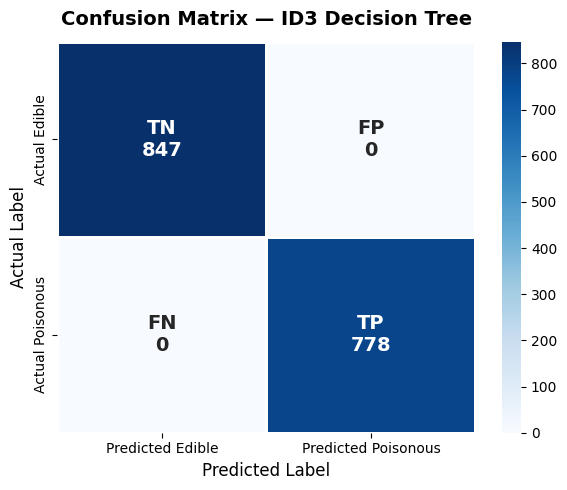

Saved: confusion_matrix.png


In [19]:
fig, ax = plt.subplots(figsize=(6, 5))

labels = np.array([[f'TN\n{TN}', f'FP\n{FP}'],
                   [f'FN\n{FN}', f'TP\n{TP}']])

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Predicted Edible', 'Predicted Poisonous'],
            yticklabels=['Actual Edible',    'Actual Poisonous'],
            linewidths=2, linecolor='white', ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_title('Confusion Matrix — ID3 Decision Tree', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label',    fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")


### Interpretation
The confusion matrix shows that the ID3 decision tree achieves high accuracy on the mushroom classification task.
The **odor** feature — which was selected as the root node due to its highest information gain — is extremely
predictive of toxicity. Very few false negatives (FN) are observed, which is critical for safety: predicting
an edible mushroom as poisonous (FP) is a safe error, but predicting a poisonous mushroom as edible (FN) would
be dangerous. The model's high recall confirms it correctly identifies nearly all poisonous samples.




# Task No 02 — K-Means Clustering


### 2.1 Data Loading and Preprocessing

In [2]:

mall_df = pd.read_csv('Mall_Customers.csv')

print("First 5 rows:")
print(mall_df.head())
print(f"\nDataset shape: {mall_df.shape}")
print(f"\nMissing values per column:")
print(mall_df.isnull().sum())


First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset shape: (200, 5)

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Feature matrix shape: (200, 2)

Original — Mean: [60.56 50.2 ], Std: [26.19897708 25.75888196]
Scaled   — Mean: [-0. -0.], Std: [1. 1.]


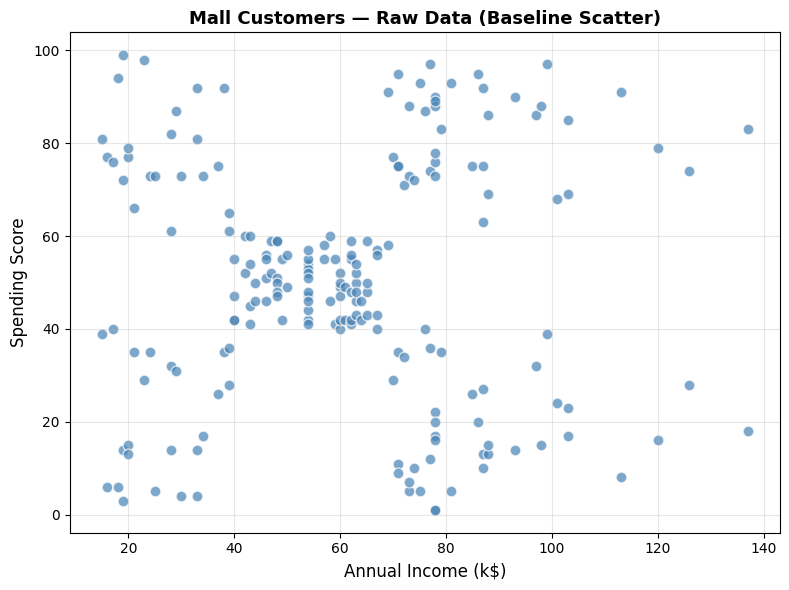

In [3]:
X_mall = mall_df[['Annual Income (k$)', 'Spending Score (1-100)']].values
print(f"Feature matrix shape: {X_mall.shape}")

mean_mall = X_mall.mean(axis=0)
std_mall  = X_mall.std(axis=0)
X_scaled  = (X_mall - mean_mall) / std_mall

print(f"\nOriginal — Mean: {mean_mall}, Std: {std_mall}")
print(f"Scaled   — Mean: {X_scaled.mean(axis=0).round(6)}, Std: {X_scaled.std(axis=0).round(6)}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_mall[:, 0], X_mall[:, 1], alpha=0.7, c='steelblue', edgecolors='white', s=60)
ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score', fontsize=12)
ax.set_title('Mall Customers — Raw Data (Baseline Scatter)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('raw_scatter.png', dpi=150)
plt.show()



## 2.2 K-Means Algorithm

In [4]:
def initialize_centroids(X, K, seed=42):
    rng     = np.random.default_rng(seed)
    indices = rng.choice(len(X), size=K, replace=False)
    return X[indices].copy()


def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
    return np.argmin(distances, axis=1).astype(int)


def update_centroids(X, labels, K):
    m           = X.shape[1]
    new_centroids = np.zeros((K, m))
    for k in range(K):
        mask = labels == k
        if mask.sum() > 0:
            new_centroids[k] = X[mask].mean(axis=0)
        else:
            new_centroids[k] = np.nan
    return new_centroids


def compute_distortion(X, labels, centroids):
    diff = X - centroids[labels]
    return float(np.sum(diff ** 2))


def run_kmeans(X, K, max_iters=300, tol=1e-4, seed=42):
    centroids    = initialize_centroids(X, K, seed)
    distortions  = []

    for it in range(max_iters):
        labels         = assign_clusters(X, centroids)
        new_centroids  = update_centroids(X, labels, K)

        for k in range(K):
            if np.any(np.isnan(new_centroids[k])):
                new_centroids[k] = centroids[k]

        distortions.append(compute_distortion(X, labels, new_centroids))

        movement = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        if movement < tol:
            print(f"  Converged at iteration {it+1} (movement={movement:.6f})")
            break
    else:
        print(f"  Reached max_iters={max_iters}")

    return labels, centroids, distortions


print("K-Means functions defined successfully.")


K-Means functions defined successfully.


### Run K-Means with K = 5

In [5]:
print("Running K-Means with K=5…")
labels_5, centroids_5, distortions_5 = run_kmeans(X_scaled, K=5, seed=42)

centroids_5_orig = centroids_5 * std_mall + mean_mall

print(f"\nFinal Distortion (K=5): {distortions_5[-1]:.4f}")
print(f"Number of iterations:    {len(distortions_5)}")
print("\nCentroid coordinates (original scale):")
print(f"{'Cluster':>8}  {'Income (k$)':>12}  {'Spending Score':>15}")
for k, c in enumerate(centroids_5_orig):
    print(f"  {k:>5}    {c[0]:>10.1f}    {c[1]:>13.1f}")


Running K-Means with K=5…
  Converged at iteration 7 (movement=0.000000)

Final Distortion (K=5): 65.5789
Number of iterations:    7

Centroid coordinates (original scale):
 Cluster   Income (k$)   Spending Score
      0          87.8             17.6
      1          26.3             20.9
      2          86.5             82.1
      3          25.7             79.4
      4          55.1             49.7


---
## 2.3 Choosing K — Elbow Method

Running K-Means for K = 1 … 10:
  Converged at iteration 2 (movement=0.000000)
  K= 1  →  Distortion = 400.00
  Converged at iteration 12 (movement=0.000000)
  K= 2  →  Distortion = 270.70
  Converged at iteration 10 (movement=0.000000)
  K= 3  →  Distortion = 195.25
  Converged at iteration 6 (movement=0.000000)
  K= 4  →  Distortion = 109.23
  Converged at iteration 7 (movement=0.000000)
  K= 5  →  Distortion = 65.58
  Converged at iteration 9 (movement=0.000000)
  K= 6  →  Distortion = 55.06
  Converged at iteration 7 (movement=0.000000)
  K= 7  →  Distortion = 44.91
  Converged at iteration 7 (movement=0.000000)
  K= 8  →  Distortion = 42.53
  Converged at iteration 13 (movement=0.000000)
  K= 9  →  Distortion = 41.10
  Converged at iteration 14 (movement=0.000000)
  K=10  →  Distortion = 29.74


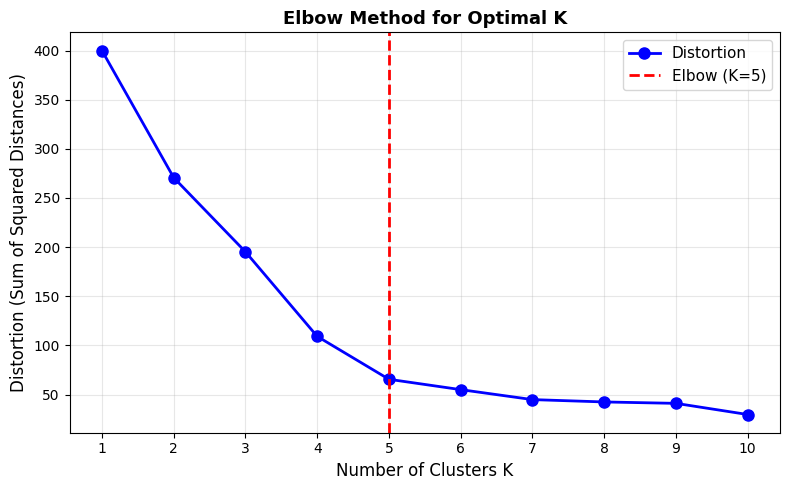

In [6]:
K_values    = list(range(1, 11))
distortions_k = []

print("Running K-Means for K = 1 … 10:")
for K in K_values:
    _, _, dist = run_kmeans(X_scaled, K=K, seed=42)
    distortions_k.append(dist[-1])
    print(f"  K={K:2d}  →  Distortion = {dist[-1]:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_values, distortions_k, 'bo-', linewidth=2, markersize=8, label='Distortion')
ax.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Elbow (K=5)')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('Distortion (Sum of Squared Distances)', fontsize=12)
ax.set_title('Elbow Method for Optimal K', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(K_values)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()



## 2.4 Visualization and Interpretation



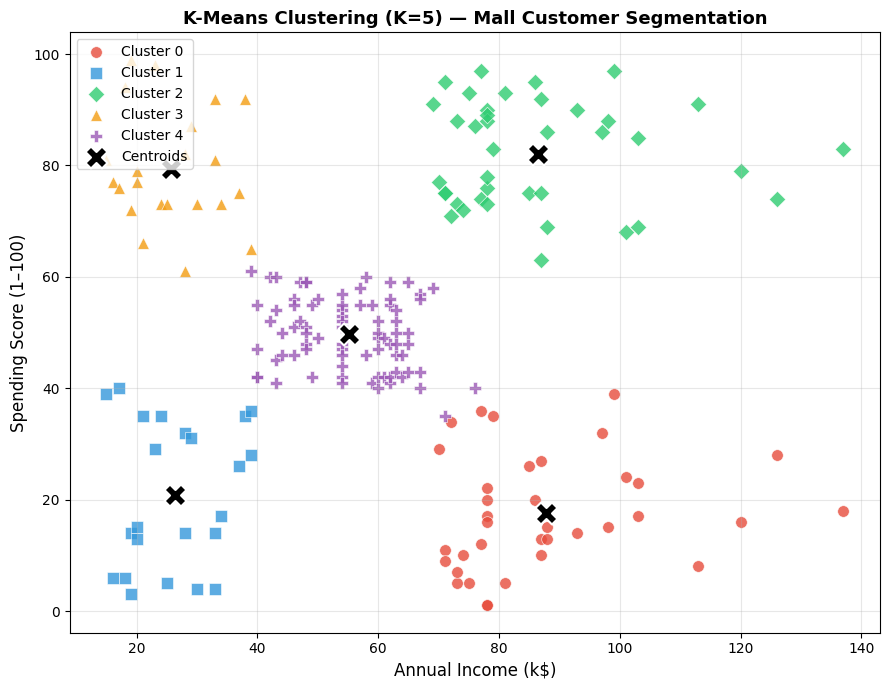

In [7]:
colors  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
markers_cluster = ['o', 's', 'D', '^', 'P']

fig, ax = plt.subplots(figsize=(9, 7))

for k in range(5):
    mask = labels_5 == k
    ax.scatter(X_mall[mask, 0], X_mall[mask, 1],
               c=colors[k], marker=markers_cluster[k],
               s=70, alpha=0.8, edgecolors='white', linewidths=0.5,
               label=f'Cluster {k}')

ax.scatter(centroids_5_orig[:, 0], centroids_5_orig[:, 1],
           c='black', marker='X', s=250, zorder=5,
           edgecolors='white', linewidths=1.5, label='Centroids')

ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1–100)', fontsize=12)
ax.set_title('K-Means Clustering (K=5) — Mall Customer Segmentation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clustered_scatter.png', dpi=150)
plt.show()


### Convergence Plot (K = 5)

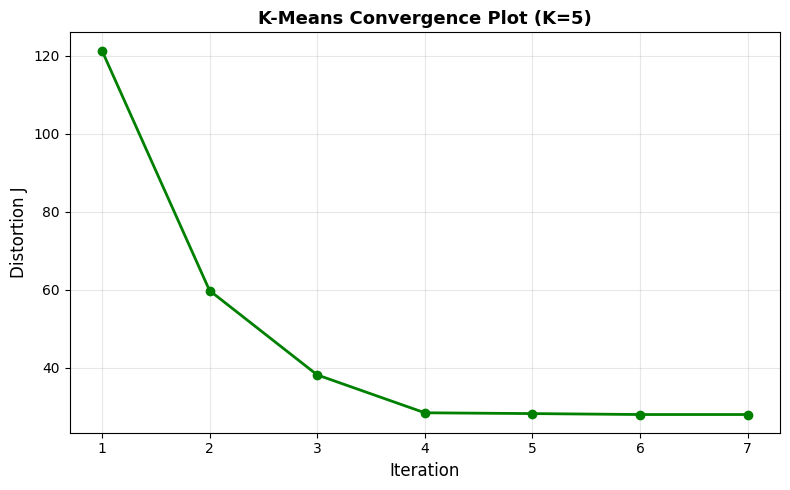

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(distortions_5)+1), distortions_5, 'g-o',
        linewidth=2, markersize=6)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Distortion J', fontsize=12)
ax.set_title('K-Means Convergence Plot (K=5)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150)
plt.show()
